In [33]:
from pathlib import Path

import cv2
import einops
import numpy as np
import torch
from matplotlib import pyplot as plt

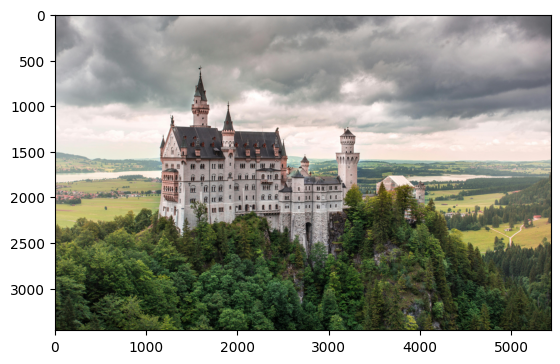

In [34]:
img = cv2.imread("./input/img_01.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [35]:
img.shape

(3457, 5436, 3)

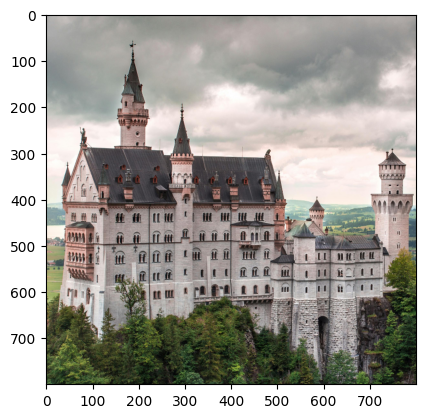

In [55]:
x_start = 400
y_start = 1050
leng = 2300

img_2 = img[x_start : x_start + leng, y_start : y_start + leng, :]
img_2 = cv2.resize(img_2, (800, 800))
plt.imshow(img_2)

In [56]:
img_2 = cv2.cvtColor(img_2, cv2.COLOR_RGB2BGR)
Path("./output").mkdir(parents=True, exist_ok=True)
cv2.imwrite("./output/img_02.jpg", img_2)

True

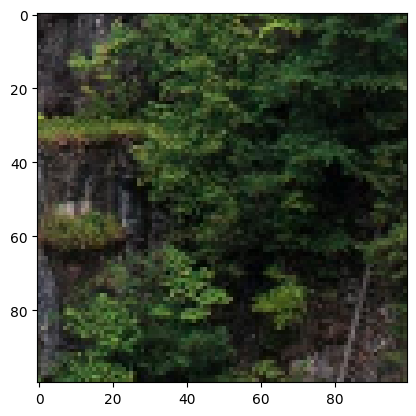

In [57]:
img_3 = einops.rearrange(
    torch.from_numpy(img_2),
    "(n_h h) (n_w w) c -> n_h n_w h w c",
    n_h=8,
    n_w=8,
)

for i in range(8):
    for j in range(8):
        block = np.asarray(img_3[i, j, ...])
        plt.imshow(cv2.cvtColor(block, cv2.COLOR_BGR2RGB))
        cv2.imwrite(f"./output/img_03_{i * 8 + j}.jpg", block)